 Customer Satisfaction Prediction

An advanced machine learning project to predict customer satisfaction using synthetic data.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
!pip install faker

In [67]:
import pandas as pd
import random
from faker import Faker
from datetime import timedelta

fake = Faker()

# Define sample values
products = ['Laptop', 'Smartphone', 'Tablet', 'Monitor', 'Printer']
ticket_types = ['Technical', 'Billing', 'Account', 'Feedback']
statuses = ['Open', 'In Progress', 'Resolved', 'Closed']
resolutions = ['Fixed', 'Refunded', 'Replaced', 'Not Resolved']
priorities = ['Low', 'Medium', 'High', 'Urgent']
channels = ['Email', 'Phone', 'Chat', 'Web Form']
genders = ['Male', 'Female', 'Other']

# Generate synthetic data
def generate_ticket(ticket_id):
    name = fake.name()
    email = fake.email()
    age = random.randint(18, 70)
    gender = random.choice(genders)
    product = random.choice(products)
    purchase_date = fake.date_between(start_date='-2y', end_date='today')
    ticket_type = random.choice(ticket_types)
    subject = f"{ticket_type} issue with {product}"
    description = fake.text(max_nb_chars=100)
    status = random.choice(statuses)
    resolution = random.choice(resolutions)
    priority = random.choice(priorities)
    channel = random.choice(channels)
    first_response = round(random.uniform(0.5, 24), 2)  # in hours
    resolution_time = round(first_response + random.uniform(1, 72), 2)
    satisfaction = random.randint(1, 5)

    return [
        ticket_id, name, email, age, gender, product,
        purchase_date, ticket_type, subject, description,
        status, resolution, priority, channel,
        first_response, resolution_time, satisfaction
    ]

# Create DataFrame
columns = [
    "Ticket ID", "Customer Name", "Customer Email", "Customer Age", "Customer Gender",
    "Product Purchased", "Date of Purchase", "Ticket Type", "Ticket Subject",
    "Ticket Description", "Ticket Status", "Resolution", "Ticket Priority",
    "Ticket Channel", "First Response Time", "Time to Resolution", "Customer Satisfaction Rating"
]

data = [generate_ticket(i+1) for i in range(100)]  # generate 100 tickets
df = pd.DataFrame(data, columns=columns)

# Save to CSV
df.to_csv("customer_satisfaction_data.csv", index=False)
print("Dataset saved as 'customer_satisfaction_data.csv'")


Dataset saved as 'customer_satisfaction_data.csv'


In [68]:
# Load the synthetic dataset
df = pd.read_csv("/content/customer_satisfaction_data.csv")
df.head()
Data = df[:]

In [69]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Dawn Hall,simpsontasha@example.net,56,Female,Smartphone,2024-01-14,Account,Account issue with Smartphone,Hotel bank run. Magazine may explain take.\nOf...,Open,Fixed,Medium,Chat,2.54,21.59,2
1,2,Lori Conner,john25@example.com,35,Other,Monitor,2024-02-24,Technical,Technical issue with Monitor,Wait artist talk body. Very low possible throu...,Resolved,Replaced,High,Web Form,17.06,44.81,5
2,3,Richard Bush,merrittnatasha@example.org,33,Other,Tablet,2023-08-25,Technical,Technical issue with Tablet,Four just lose.,Resolved,Fixed,Low,Phone,6.97,45.49,5
3,4,Megan Williams,iaguirre@example.net,67,Male,Laptop,2025-04-16,Feedback,Feedback issue with Laptop,Good window any. Price debate leader evidence ...,Resolved,Not Resolved,Medium,Chat,18.09,44.90,1
4,5,Megan Sanders,pwebb@example.com,29,Female,Smartphone,2025-07-16,Account,Account issue with Smartphone,Travel decision minute size. Clearly leg exper...,In Progress,Refunded,Low,Chat,4.14,9.07,4


In [70]:
# Check for nulls and types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     100 non-null    int64  
 1   Customer Name                 100 non-null    object 
 2   Customer Email                100 non-null    object 
 3   Customer Age                  100 non-null    int64  
 4   Customer Gender               100 non-null    object 
 5   Product Purchased             100 non-null    object 
 6   Date of Purchase              100 non-null    object 
 7   Ticket Type                   100 non-null    object 
 8   Ticket Subject                100 non-null    object 
 9   Ticket Description            100 non-null    object 
 10  Ticket Status                 100 non-null    object 
 11  Resolution                    100 non-null    object 
 12  Ticket Priority               100 non-null    object 
 13  Ticket

In [71]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

Label = LabelEncoder()
for i in df.columns:
  if df[i].dtype == 'object':
    df[i] = Label.fit_transform(df[i])

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,21,87,56,0,3,25,0,3,47,2,0,2,0,2.54,21.59,2
1,2,61,36,35,2,1,30,3,16,92,3,3,0,3,17.06,44.81,5
2,3,82,62,33,2,4,6,3,19,41,3,0,1,2,6.97,45.49,5
3,4,69,30,67,1,0,82,2,10,44,3,1,2,0,18.09,44.90,1
4,5,68,80,29,0,3,95,0,3,85,1,2,1,0,4.14,9.07,4


In [72]:
print(df.describe())

        Ticket ID  Customer Name  Customer Email  Customer Age  \
count  100.000000     100.000000      100.000000    100.000000   
mean    50.500000      49.500000       49.500000     43.150000   
std     29.011492      29.011492       29.011492     15.381594   
min      1.000000       0.000000        0.000000     18.000000   
25%     25.750000      24.750000       24.750000     32.000000   
50%     50.500000      49.500000       49.500000     42.000000   
75%     75.250000      74.250000       74.250000     56.000000   
max    100.000000      99.000000       99.000000     69.000000   

       Customer Gender  Product Purchased  Date of Purchase  Ticket Type  \
count       100.000000         100.000000        100.000000   100.000000   
mean          1.220000           2.030000         47.400000     1.580000   
std           0.811284           1.336776         28.061261     1.093415   
min           0.000000           0.000000          0.000000     0.000000   
25%           1.000000   

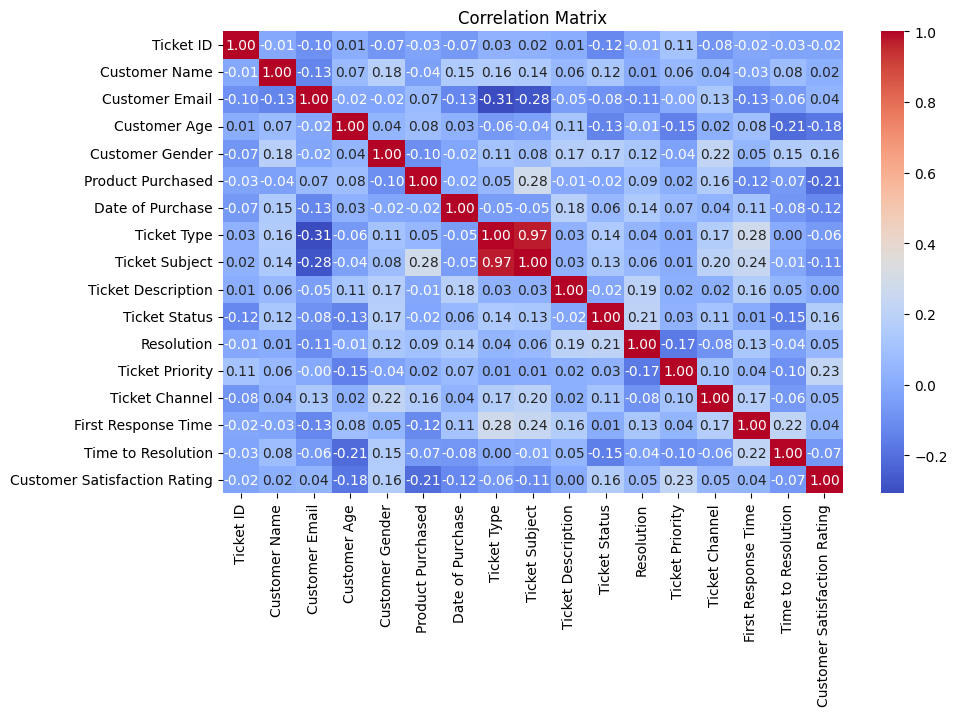

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [74]:
# Define features and target
X = df.drop(['Ticket ID','Product Purchased', 'Ticket Status','Ticket Channel'], axis=1)
y = df['Customer Satisfaction Rating']


In [75]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [76]:
# Train a Random Forest Classifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
# Predict
y_pred = rfc.predict(X_test)


In [77]:
# Evaluation
print('Temperature Anomaly Model')
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

Temperature Anomaly Model
MAE: 0.13333333333333333
MSE: 0.13333333333333333
R2: 0.9233226837060703


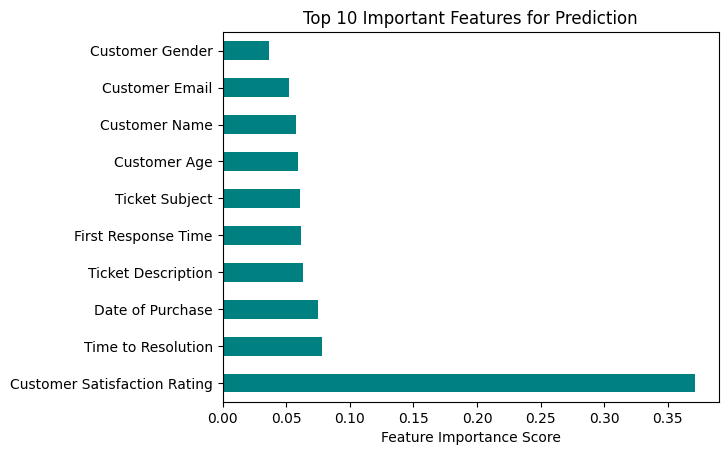

In [78]:
# Feature Importance
importances = pd.Series(rfc.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Important Features for Prediction')
plt.xlabel('Feature Importance Score')
plt.show()

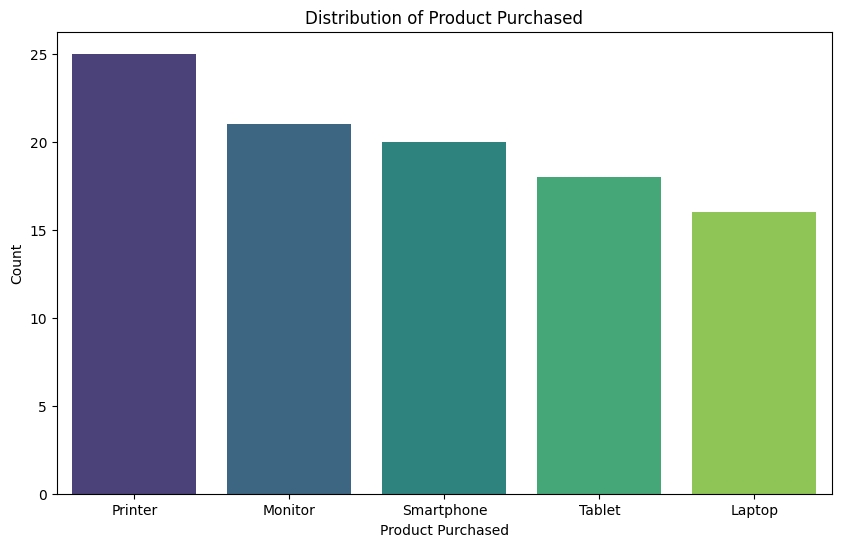

In [81]:
plt.figure(figsize=(10, 6))
product_purchased_distribution = Data['Product Purchased'].value_counts()
sns.barplot(x=product_purchased_distribution.index, y=product_purchased_distribution.values, palette='viridis')
plt.title('Distribution of Product Purchased')
plt.xlabel('Product Purchased')
plt.ylabel('Count')
plt.show()